# Instructions

(1) In mod08_sustainability_calculations, the energy usage is the product of the number of CPU cores, the number of runtime hours, and the number of kilowatts used per core. Update the function "compute_energy_kwh" to reflect this. _Hint_: You'll want to explore the data created in mod08_generate_emissions_data to learn the appropriate variable names.

(2) After you've updated (and saved) mod08_sustainability_calculations, run the cells in this notebook and answer the three discussion question. 

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from mod08_generate_emissions_data import generate_data
from mod08_sustainability_calculations import (
    compute_energy_kwh,
    compute_emissions,
    emissions_by_region,
    compute_total_runtime
)

### Get the data

In [24]:
jobs, carbon_intensity, power_per_core_kw, max_cores_per_region = generate_data()

### Inspect the Provided Data

In [25]:
print("Jobs Dataset:")
print(jobs)

print("\nCarbon Intensity by Region (kg CO2 per kWh):")
for region, intensity in carbon_intensity.items():
    print(f"{region}: {intensity}")

Jobs Dataset:
    job_id  cpu_cores  runtime_hours
0        1          1           0.50
1        2          2           1.20
2        3          4           0.75
3        4          8           2.50
4        5          2           1.00
5        6          1           0.30
6        7         16           3.00
7        8          4           1.50
8        9          8           2.00
9       10          2           0.80
10      11          4           0.50
11      12          8           2.25
12      13          2           1.60
13      14          8           0.90
14      15         16           1.10

Carbon Intensity by Region (kg CO2 per kWh):
coal_heavy_region: 0.9
renewable_region: 0.05


### Compute Energy Usage

In [26]:
jobs_with_energy = compute_energy_kwh(jobs, power_per_core_kw)

print("Jobs with Energy Computed:")
print(jobs_with_energy)

total_energy = jobs_with_energy["energy_kwh"].sum()
print(f"\nTotal Energy Consumption: {total_energy:.4f} kWh")

Jobs with Energy Computed:
    job_id  cpu_cores  runtime_hours  energy_kwh
0        1          1           0.50       0.025
1        2          2           1.20       0.120
2        3          4           0.75       0.150
3        4          8           2.50       1.000
4        5          2           1.00       0.100
5        6          1           0.30       0.015
6        7         16           3.00       2.400
7        8          4           1.50       0.300
8        9          8           2.00       0.800
9       10          2           0.80       0.080
10      11          4           0.50       0.100
11      12          8           2.25       0.900
12      13          2           1.60       0.160
13      14          8           0.90       0.360
14      15         16           1.10       0.880

Total Energy Consumption: 7.3900 kWh


### Compute Emissions for Each Region

In [27]:
region_emissions = emissions_by_region(jobs_with_energy, carbon_intensity)

print("Total Emissions by Region (kg CO2):")
for region, emissions in region_emissions.items():
    print(f"{region}: {emissions:.4f}")

Total Emissions by Region (kg CO2):
coal_heavy_region: 6.6510
renewable_region: 0.3695


### Visualize Emissions by Region

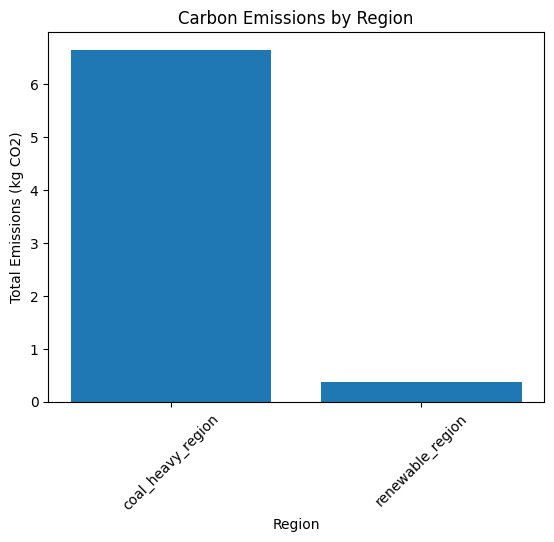

In [28]:
plt.figure()
plt.bar(region_emissions.keys(), region_emissions.values())
plt.xlabel("Region")
plt.ylabel("Total Emissions (kg CO2)")
plt.title("Carbon Emissions by Region")
plt.xticks(rotation=45)
plt.show()

### Scenario 1: All Jobs in Coal-Heavy Region

In [29]:
coal_region = max(carbon_intensity, key=carbon_intensity.get)
all_coal_emissions = compute_emissions(
    jobs_with_energy,
    carbon_intensity[coal_region]
)

all_coal_runtime = compute_total_runtime(jobs_with_energy, max_cores_per_region[coal_region])

print(f"All jobs in {coal_region}: {all_coal_emissions:.4f} kg CO2, Runtime: {all_coal_runtime:.2f} h")

All jobs in coal_heavy_region: 6.6510 kg CO2, Runtime: 7.10 h


### Scenario 2: All Jobs in Renewable Region

In [30]:
renewable_region = min(carbon_intensity, key=carbon_intensity.get)
all_renewable_emissions = compute_emissions(
    jobs_with_energy,
    carbon_intensity[renewable_region]
)

all_renewable_runtime = compute_total_runtime(jobs_with_energy, max_cores_per_region[renewable_region])

print(f"All jobs in {renewable_region}: {all_renewable_emissions:.4f} kg CO2, Runtime: {all_renewable_runtime:.2f} h")

All jobs in renewable_region: 0.3695 kg CO2, Runtime: 11.95 h


### Scenario 3: Assign High CPU Jobs to Renewable Region

In [31]:
# Decide which jobs to assign to renewable region
median = jobs_with_energy["cpu_cores"].median()

green_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] >= median]
dirty_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] < median]

# compute the new total emissions
smart_emissions = compute_emissions(green_jobs, carbon_intensity[renewable_region]) + \
                  compute_emissions(dirty_jobs, carbon_intensity[coal_region])

# compute the new total runtime (with parallelization)
smart_runtime = max(compute_total_runtime(green_jobs, max_cores_per_region[renewable_region]),
                    compute_total_runtime(dirty_jobs, max_cores_per_region[coal_region]))

print(f"High-CPU jobs to {renewable_region}: {smart_emissions:.4f} kg CO2, Runtime: {smart_runtime:.2f} h")

High-CPU jobs to renewable_region: 0.7945 kg CO2, Runtime: 10.10 h


### Strategy Comparison Plot

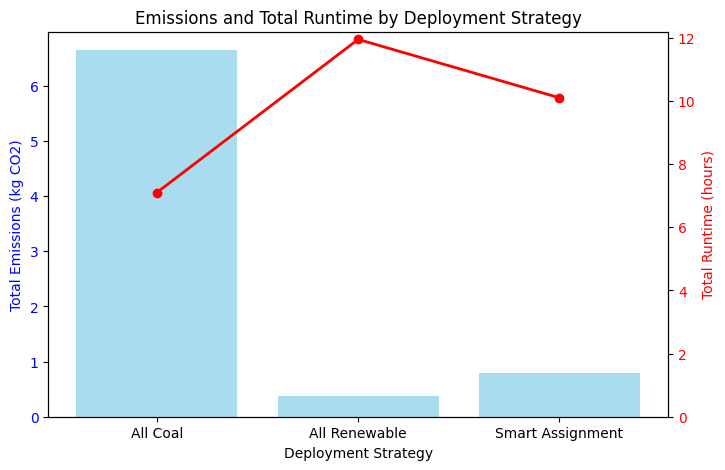

In [32]:
# Prepare data
strategy_names = ["All Coal", "All Renewable", "Smart Assignment"]
emission_values = [all_coal_emissions, all_renewable_emissions, smart_emissions]
runtime_values = [all_coal_runtime, all_renewable_runtime, smart_runtime]

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart for emissions
ax1.bar(strategy_names, emission_values, color='skyblue', alpha=0.7)
ax1.set_ylabel("Total Emissions (kg CO2)", color='blue')
ax1.set_xlabel("Deployment Strategy")
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("Emissions and Total Runtime by Deployment Strategy")

# Line chart for runtime
ax2 = ax1.twinx()
ax2.plot(strategy_names, runtime_values, color='red', marker='o', linewidth=2)
ax2.set_ylabel("Total Runtime (hours)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(bottom=0)

plt.show()

# Discussion Questions

### Similar to what we did in Scenario 3, let's look at different quantile values to decide what proportion of jobs to assign to renewable energy.

In [33]:
# Decide which jobs to assign to renewable region
cpu_threshold = jobs_with_energy["cpu_cores"].quantile(
    # enter a choice between 0 and 1 here
    0.5
)

green_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] >= cpu_threshold]
dirty_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] < cpu_threshold]

# compute the new total emissions
smart_emissions = compute_emissions(green_jobs, carbon_intensity[renewable_region]) + \
                  compute_emissions(dirty_jobs, carbon_intensity[coal_region])

# compute the new total runtime (with parallelization)
smart_runtime = max(compute_total_runtime(green_jobs, max_cores_per_region[renewable_region]),
                    compute_total_runtime(dirty_jobs, max_cores_per_region[coal_region]))

print(f"High-CPU jobs to {renewable_region}: {smart_emissions:.4f} kg CO2, Runtime: {smart_runtime:.2f} h")

High-CPU jobs to renewable_region: 0.7945 kg CO2, Runtime: 10.10 h


### Comment on what you believe is the most appropriate threshold given the tradeoff between emissions and runtime.

I believe the most appropriate threshold is around 0.5 because it  creates a good balance between lowering emissions and maintaining a reasonable runtime. At this point, the higher-CPU jobs, which use the energy, are sent to the renewable region, helping reduce total CO_2 emissions, while smaller jobs stay in the coal-heavy region so the renewable system does not become overloaded. If the threshold were lower, emissions might decrease more, but runtime would likely increase because too many jobs would be sent to the region with fewer available cores. If it were higher, runtime might imporve slightly, but the emissions savings would be smaller. Overall, a middle threshold seems like thebest tradeoff.

### In this notebook, we calculate emissions and runtimes as the inputs of our cost-benefit analysis. Name and explain at least one other cost or benefit that is not considered here.

One important factor not considered in this notebook iss the financial cost. While the notebook compares emissions and runtime, it does not account for possible differences in electricity prices, infrastructure costs, or operating expenses between regions. For example, assiging more jobs to a renewable region maay lower emissions, but it could also cost more depeendding on energy pricing or available resources. Another faactor could be system reliability, since renewaable energy vaailability may vary over time. Including cost or reliability wouldd maake the analysis more realistic and useful for decision-making.

### List at least two different stakeholders that would be affected by a strategic decision regarding the assignment of resources explored in this notebook. In your opinion, which stakeholder's interests are most compelling?

Two important staakeholders affected by this decision are the organization running the jobs and the broader public/enviroment. The organization would care most about runtime, efficiency, andd overaall system performance, since slower runtimes could reduce productivity or delay results. The broader public and environment are affected becaause higher emissions contribute to climate change and other long-term environmental problems. In my opinion, the interests of the public and the environment are the most compelling because the effects of carbon emissions extend far beyonf the company itself and can impact society as aa whole. As long as runtime remains reasonable, reducing emissions should be a maajor priority.